In [1]:
import os
import cv2
import shutil
import random

import matplotlib.pyplot as plt
import numpy as np

In [2]:
USE_AUGMENTED_DATA = True  # True = dùng augmented, False = dùng original

if USE_AUGMENTED_DATA:
    print(" Using cropped dataset")
    # SOURCE_DIR = "../data/augmented"
    SOURCE_DIR = "../data/cropped"
else:
    print(" Using ORIGINAL dataset")
    SOURCE_DIR = "../data/processed"

 Using cropped dataset


In [3]:
RAW_DIR = "../data/raw"
# PROCESSED_DIR = "../data/processed"
PROCESSED_DIR = SOURCE_DIR 
SPLIT_DIR = "../data/split"

IMG_SIZE = 224
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15


In [4]:
CLASS_MAPPING = {
    "Bacterial Leaf Blight": "bacterial_blight",
    "Barrow Brown Leaf Spot": "barrow_brown_leaf_spot",
    "Brown Spot": "brown_spot",
    "Healthy Rice Leaf": "healthy",
    "Leaf Blast": "leaf_blast",
    "Leaf Scald": "leaf_scald",
    "Leaf Smut": "leaf_smut",
    # "Neck Blast": "neck_blast",
    "Rice Hispa": "rice_hispa",
    "Sheath Blight": "sheath_blight",
    # "Tungro": "tungro"
}


In [5]:
os.makedirs(PROCESSED_DIR, exist_ok=True)

for new_name in CLASS_MAPPING.values():
    os.makedirs(os.path.join(PROCESSED_DIR, new_name), exist_ok=True)


In [6]:
# total_images = 0

# for old_name, new_name in CLASS_MAPPING.items():
#     src_dir = os.path.join(RAW_DIR, old_name)
#     dst_dir = os.path.join(PROCESSED_DIR, new_name)

#     for img_name in os.listdir(src_dir):
#         img_path = os.path.join(src_dir, img_name)
#         img = cv2.imread(img_path)

#         if img is None:
#             continue

#         img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
#         save_path = os.path.join(dst_dir, img_name)
#         cv2.imwrite(save_path, img)
#         total_images += 1

# print("Đã xử lý", total_images, "ảnh")

if USE_AUGMENTED_DATA:
    print(" Using pre-augmented data, skipping resize step")
    total_images = sum([len(os.listdir(os.path.join(PROCESSED_DIR, cls))) 
                       for cls in CLASS_MAPPING.values()])
    print(f" Found {total_images} augmented images")
else:
    # Original code
    total_images = 0
    for old_name, new_name in CLASS_MAPPING.items():
        src_dir = os.path.join(RAW_DIR, old_name)
        dst_dir = os.path.join(PROCESSED_DIR, new_name)

        for img_name in os.listdir(src_dir):
            img_path = os.path.join(src_dir, img_name)
            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            save_path = os.path.join(dst_dir, img_name)
            cv2.imwrite(save_path, img)
            total_images += 1

    print(" Đã xử lý", total_images, "ảnh")

 Using pre-augmented data, skipping resize step
 Found 28750 augmented images


In [7]:
for split in ["train", "val", "test"]:
    for class_name in CLASS_MAPPING.values():
        os.makedirs(os.path.join(SPLIT_DIR, split, class_name), exist_ok=True)


In [8]:
random.seed(42)

for class_name in CLASS_MAPPING.values():
    images = os.listdir(os.path.join(PROCESSED_DIR, class_name))
    random.shuffle(images)

    total = len(images)
    train_end = int(total * TRAIN_RATIO)
    val_end = int(total * (TRAIN_RATIO + VAL_RATIO))

    splits = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split, files in splits.items():
        for f in files:
            src = os.path.join(PROCESSED_DIR, class_name, f)
            dst = os.path.join(SPLIT_DIR, split, class_name, f)
            shutil.copy(src, dst)

print("Chia dữ liệu hoàn tất")


Chia dữ liệu hoàn tất


In [9]:
for split in ["train", "val", "test"]:
    print(f"\n {split.upper()}")
    for class_name in CLASS_MAPPING.values():
        path = os.path.join(SPLIT_DIR, split, class_name)
        print(f"{class_name:20s}: {len(os.listdir(path))}")



 TRAIN
bacterial_blight    : 2808
barrow_brown_leaf_spot: 1407
brown_spot          : 3569
healthy             : 2875
leaf_blast          : 3497
leaf_scald          : 2106
leaf_smut           : 216
rice_hispa          : 1402
sheath_blight       : 2240

 VAL
bacterial_blight    : 602
barrow_brown_leaf_spot: 302
brown_spot          : 765
healthy             : 616
leaf_blast          : 750
leaf_scald          : 451
leaf_smut           : 46
rice_hispa          : 301
sheath_blight       : 480

 TEST
bacterial_blight    : 602
barrow_brown_leaf_spot: 302
brown_spot          : 765
healthy             : 617
leaf_blast          : 750
leaf_scald          : 452
leaf_smut           : 47
rice_hispa          : 301
sheath_blight       : 481


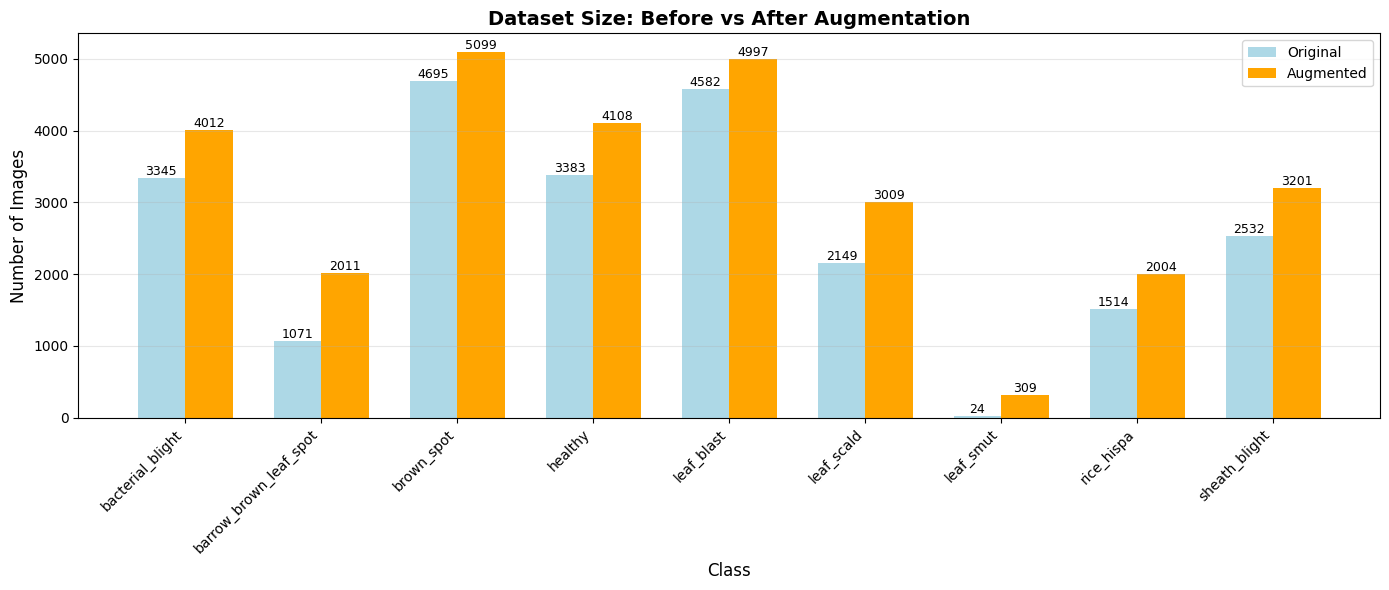


DATASET SIZE COMPARISON
Class                       Original  Augmented   Increase
----------------------------------------------------------------------
bacterial_blight                3345       4012      19.9%
barrow_brown_leaf_spot          1071       2011      87.8%
brown_spot                      4695       5099       8.6%
healthy                         3383       4108      21.4%
leaf_blast                      4582       4997       9.1%
leaf_scald                      2149       3009      40.0%
leaf_smut                         24        309    1187.5%
rice_hispa                      1514       2004      32.4%
sheath_blight                   2532       3201      26.4%
TOTAL                          23295      28750      23.4%

 Visualization saved to ../models/dataset_comparison.png


In [10]:
# So sánh số lượng
original_counts = {}
augmented_counts = {}

for class_name in CLASS_MAPPING.values():
    # Original
    orig_dir = os.path.join("../data/processed", class_name)
    if os.path.exists(orig_dir):
        original_counts[class_name] = len([f for f in os.listdir(orig_dir) 
                                           if f.endswith(('.jpg', '.jpeg', '.png'))])
    
    # Augmented (if exists)
    aug_dir = os.path.join("../data/augmented", class_name)
    if os.path.exists(aug_dir):
        augmented_counts[class_name] = len([f for f in os.listdir(aug_dir) 
                                            if f.endswith(('.jpg', '.jpeg', '.png'))])
    else:
        augmented_counts[class_name] = original_counts.get(class_name, 0)

# Visualize
classes = list(CLASS_MAPPING.values())
orig_vals = [original_counts.get(c, 0) for c in classes]
aug_vals = [augmented_counts.get(c, 0) for c in classes]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, orig_vals, width, label='Original', color='lightblue')
bars2 = ax.bar(x + width/2, aug_vals, width, label='Augmented', color='orange')

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Dataset Size: Before vs After Augmentation', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../models/dataset_comparison.png', dpi=150)
plt.show()

# Print summary
print("\n" + "="*70)
print("DATASET SIZE COMPARISON")
print("="*70)
print(f"{'Class':25s} {'Original':>10s} {'Augmented':>10s} {'Increase':>10s}")
print("-"*70)

total_orig = 0
total_aug = 0

for class_name in classes:
    orig = original_counts.get(class_name, 0)
    aug = augmented_counts.get(class_name, 0)
    increase = ((aug - orig) / orig * 100) if orig > 0 else 0
    
    total_orig += orig
    total_aug += aug
    
    print(f"{class_name:25s} {orig:10d} {aug:10d} {increase:9.1f}%")

print("="*70)
print(f"{'TOTAL':25s} {total_orig:10d} {total_aug:10d} {(total_aug-total_orig)/total_orig*100:9.1f}%")
print("="*70)

print(f"\n Visualization saved to ../models/dataset_comparison.png")